[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/Hbretonniere/VHIO_academy_DL_Intro_Course/blob/main/notebooks/3-CNN_brain_tumour.ipynb)

# #3 Convolutional Neural Network classification

In this notebook, we are training a more complex model for a task that would be quite hard to do without deep learning: classification of complex images

In [1]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy import stats
import torch.nn as nn
import sklearn
import seaborn as sns
import cv2
from torchinfo import summary


Fixing the seeds for replicability

In [2]:
seed = 50

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False



## Data
Our images comes from the Kaggle challenge of brain tumour classification. We are going to use only 2 classes, glioma and healthy patients, and try to classify them using only images.

You can find more details about the experiment here: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

We need to homogenise our data, that do not necessarily have the same colors (some RGB, some black and white), and also not the same size in term of pixels. We "downgrade" all the data to be black and white and 224x224 pixels.

In [3]:
path = '../data'

In [4]:
# ## If you are in google collab, uncomment this cell and run it:
# ## It will ask you to uplad a file, upload brain_tumours.zip from the local data folder

# from google.colab import files
# uploaded = files.upload()
# !unzip brain_tumours.zip
# path = '.'


In [5]:

def load_tumour_healthy(training_or_testing):
    ## Glioma images
    imgs_glioma = []
    for img_name in glob.glob(f'{path}/brain_tumours/{training_or_testing}/glioma/*.jpg'):
        im = cv2.imread(img_name)
        
        if len(np.shape(im)) == 3:
            im = np.array(im)[..., -1]
        im = cv2.resize(im, dsize=(224, 224), interpolation=cv2.INTER_CUBIC)
        imgs_glioma.append(im)

    ## Healthy images
    imgs_no_tumour = []
    for img_name in glob.glob(f'{path}/brain_tumours/{training_or_testing}/notumor/*.jpg'):
        im = cv2.imread(img_name)
        
        if len(np.shape(im)) == 3:
            im = np.array(im)[..., -1]
        im = cv2.resize(im, dsize=(224, 224), interpolation=cv2.INTER_CUBIC)
        imgs_no_tumour.append(im)
    return imgs_glioma, imgs_no_tumour

In [6]:
imgs_glioma, imgs_no_tumour = load_tumour_healthy('Training')

Text(0.5, 0.98, 'Tumour images                                                                                                        Healthy images')

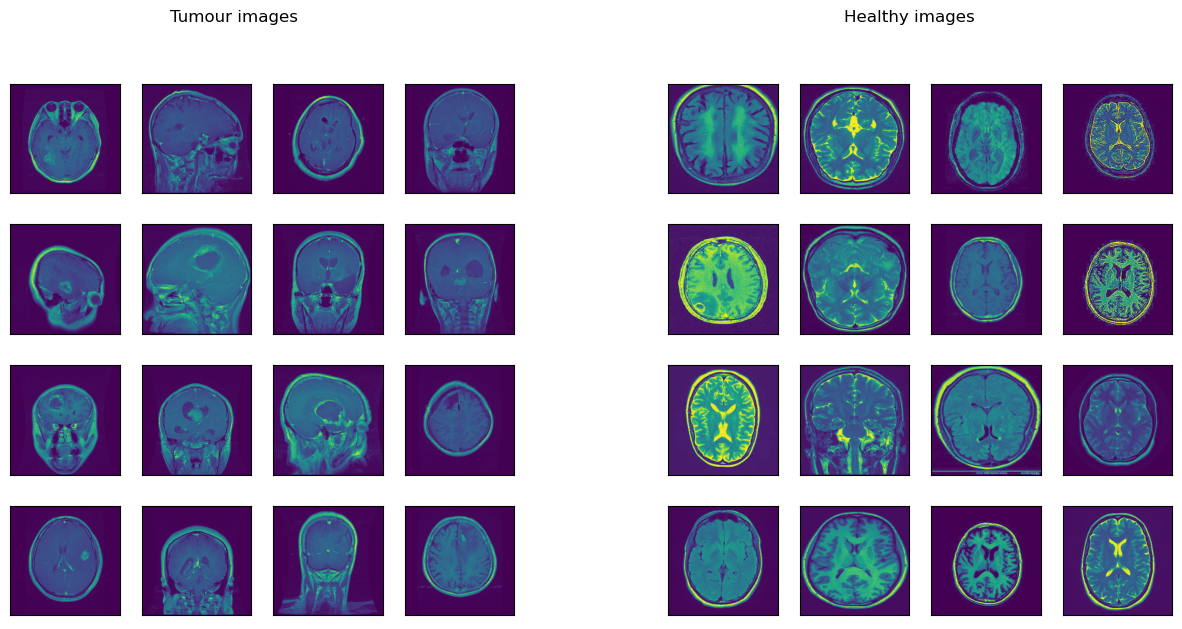

In [7]:
fig, ax = plt.subplots(4, 9, figsize=(15, 7))
k = 0
for i in range(4):
    for j in range(4):
        ax[i, j].imshow(imgs_glioma[k])
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        k += 1

k = 0
for i in range(4):
    for j in range(4):
        ax[i, j+5].imshow(imgs_no_tumour[k])
        ax[i, j+5].set_xticks([])
        ax[i, j+5].set_yticks([])
        k += 1

[axe.set_axis_off() for axe in ax[:, 4]]
plt.suptitle('Tumour images                                                                                                        Healthy images') 

## Ground truth
We need to construct our labels. It's pretty easy to do: we assign 0 for healthy, 1 for glioma, using that our n first imaged are glioma and the rest is healthy

In [8]:
y = np.zeros(len(imgs_glioma) + len(imgs_no_tumour))
y[:len(imgs_glioma)] = 1
x = np.concatenate((imgs_glioma, imgs_no_tumour))
shuffle = np.random.permutation(np.arange(0, len(x)))
x = x[shuffle]
y = y[shuffle]

## Normalisation
Our data is more standardized than the previous example. No need of lo scale here, we are just goin to take off the mean and divide by std.

Text(0.5, 1.0, 'pixel distribution over all images, normalised')

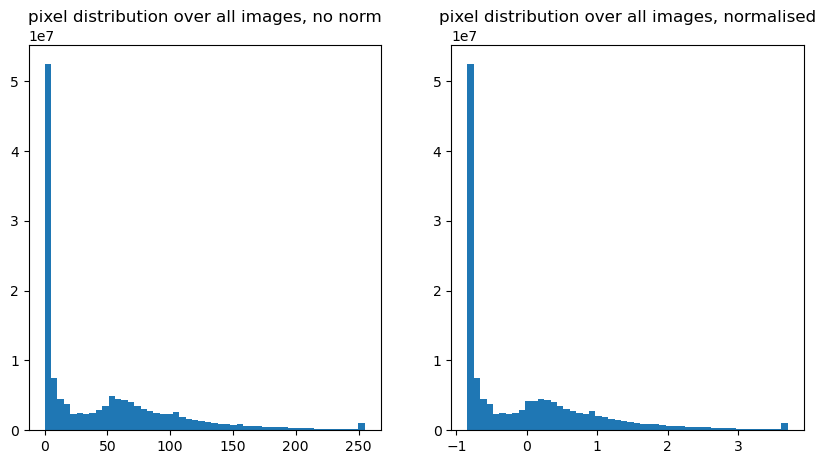

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(x.ravel(), bins=50)
x_norm = (x - np.mean(x)) / np.std(x)
ax[1].hist(x_norm.ravel(), bins=50)
ax[0].set_title('pixel distribution over all images, no norm')
ax[1].set_title('pixel distribution over all images, normalised')

## Data preparation
Here again, we transform our data to torch tensors, train and test splits, and batch them.

Even if we are black and white, we need a "channel" dimmension, that we put as the first dimension. This is because as we've seen in the course, a CNN is learning new representation of the data, that you can thinl about as channels, or "colors". Instead of being (3, 225, 225) (a RGB image), we're going to learn a (n, 255, 255) representation of the image, n being the number of kernels in the layers.


In [10]:

# set the number of samples per group
n_train_samples = int(0.6*len(x_norm))
n_validation_samples = int(0.2*len(x_norm))
n_test_samples = int(0.2*len(x_norm))

# randomise your data for random reprentation in each group
random_samples_ids = np.arange(len(x_norm))
np.random.shuffle(random_samples_ids)

# get the random ids
train_ids = random_samples_ids[:n_train_samples]
validation_ids = random_samples_ids[n_train_samples:n_train_samples+n_validation_samples]
test_ids = random_samples_ids[-n_test_samples:]

# create the sets
x_train = x_norm[train_ids]
y_train = y[train_ids]

x_validation = x_norm[validation_ids]
y_validation = y[validation_ids]

x_test = x_norm[test_ids]
y_test = y[test_ids]

In [11]:
x_train = torch.from_numpy(np.expand_dims(x_train, 0)).float()
y_train = torch.from_numpy(np.expand_dims(y_train, 1)).float()
x_train = x_train.transpose(0, 1) # transpose to have a shape (n_images, n_channels, height, width)

x_validation = torch.from_numpy(np.expand_dims(x_validation, 0)).float()
y_validation = torch.from_numpy(np.expand_dims(y_validation, 1)).float()
x_validation = x_validation.transpose(0, 1) # transpose to have a shape (n_images, n_channels, height, width)

x_test = torch.from_numpy(np.expand_dims(x_test, 0)).float()
y_test = torch.from_numpy(np.expand_dims(y_test, 1)).float()
x_test = x_test.transpose(0, 1) # transpose to have a shape (n_images, n_channels, height, width)

In [12]:
print(f'train shape: {x_train.shape}')
print(f'validation shape: {x_validation.shape}')
print(f'test shape: {x_test.shape}')

train shape: torch.Size([1680, 1, 224, 224])
validation shape: torch.Size([560, 1, 224, 224])
test shape: torch.Size([560, 1, 224, 224])


## Model definition
We define our model: 
We first have a CNN, that compress the image (stride of 2) with batch norm and ReLU activation. The CNN compress the spatial infornation and increase the feature information.

After going to a more reduced non spatial features, we use a classic NN for the final prediction. 

The model is big, it starts to be long to train on CPU...

In [13]:
class GliomaCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 16, 3, padding=1, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, 3, padding=1, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, padding=1, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))   # avoids manual flatten size
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1)   # binary output
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [14]:
model_simple = GliomaCNN()

In [15]:
# model_simple = model_simple()
total_params = sum(p.numel() for p in model_simple.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 105953


In [16]:
summary(model_simple, input_size=(32, 1, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
GliomaCNN                                [32, 1]                   --
├─Sequential: 1-1                        [32, 128, 1, 1]           --
│    └─Conv2d: 2-1                       [32, 16, 112, 112]        160
│    └─BatchNorm2d: 2-2                  [32, 16, 112, 112]        32
│    └─ReLU: 2-3                         [32, 16, 112, 112]        --
│    └─Conv2d: 2-4                       [32, 32, 56, 56]          4,640
│    └─BatchNorm2d: 2-5                  [32, 32, 56, 56]          64
│    └─ReLU: 2-6                         [32, 32, 56, 56]          --
│    └─Conv2d: 2-7                       [32, 64, 28, 28]          18,496
│    └─BatchNorm2d: 2-8                  [32, 64, 28, 28]          128
│    └─ReLU: 2-9                         [32, 64, 28, 28]          --
│    └─Conv2d: 2-10                      [32, 128, 14, 14]         73,856
│    └─BatchNorm2d: 2-11                 [32, 128, 14, 14]         256
│

### Optimisation
For binary classification, it's good to use a more statistical probability loss: hte binary corss entropy. As we are not using last ctivation, the loss is first applying a sigmoid to the output, which trasnform the output to a [0, 1] range, i.e. a valid probability

In [17]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_simple.parameters(), lr = 0.001)

# Training
The training model is the exact same as before. Our model is just more complex

In [18]:
n_train_samples

1680

In [19]:
y_train.shape

torch.Size([1680, 1])

In [20]:
x_train.shape

torch.Size([1680, 1, 224, 224])

In [21]:
def train_model(model, batch_size, optimizer):
    losses_steps = []
    losses_epochs = []
    validation_losses = []
    for epoch in range(5):
        loss_epoch = 0

        #shuffle the trainig data each epoch for better stochasticity
        indices = torch.randperm(n_train_samples)
        x_shuffled = x_train[indices]
        y_shuffled = y_train[indices]

        # loop through the dataset per batch
        for i, start_idx in enumerate(range(0, n_train_samples, batch_size)):
            
            # take only the current batch
            end_idx = start_idx + batch_size
            x_batch = x_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            # use the model to predict on the batch
            pred_y = model(x_batch)

            # Compute the loss on the batch and log it
            loss = criterion(pred_y, y_batch)
            loss_epoch += loss.detach().numpy()
            losses_steps.append(loss.detach().numpy())

            # Zero gradients (not accumulate)
            optimizer.zero_grad()
            
            # compute the gradients
            loss.backward()

            # apply the gradients to optimise
            optimizer.step()
            
        # Compute the mean loss on the epoch
        pred_val_y = model(x_validation)
        val_loss = criterion(pred_val_y, y_validation)
        validation_losses.append(val_loss.detach().numpy())
        losses_epochs.append(loss_epoch / i)
    return losses_epochs, losses_steps, validation_losses


In [22]:
losses_epochs, losses_steps, validation_losses = train_model(model_simple, 32, optimizer)

<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_48196/2360396341.py:13: SyntaxWarning: invalid escape sequence '\h'
  [axe.set_ylabel('MSE \n ($|\hat{y} - y|^2)$', fontsize=13) for axe in ax]
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_48196/2360396341.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


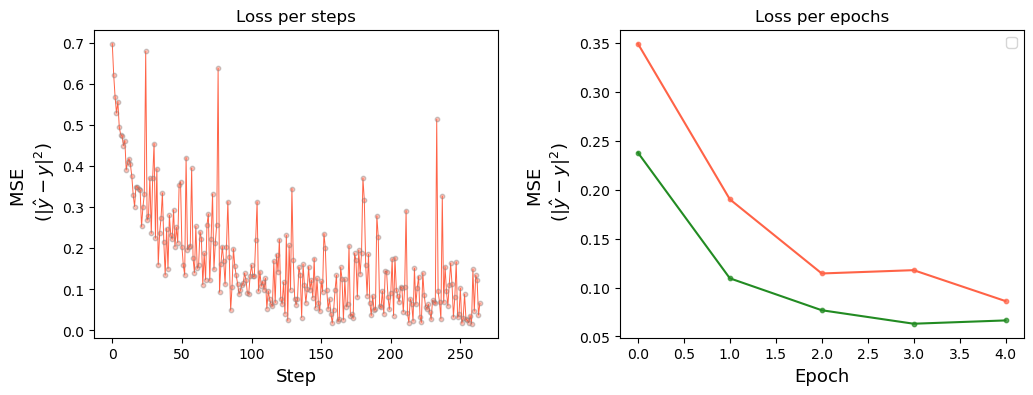

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3)
ax[0].scatter(np.arange(len(losses_steps)), losses_steps, alpha=0.4, s=10, c='tomato', zorder=5, edgecolors='gray')
ax[0].plot(np.arange(len(losses_steps)), losses_steps, c='tomato', lw=.7)


ax[1].scatter(np.arange(len(losses_epochs)), losses_epochs, alpha=0.7, s=10, c='tomato', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), losses_epochs, c='tomato')
ax[1].scatter(np.arange(len(losses_epochs)), validation_losses, alpha=0.7, s=10, c='forestgreen', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), validation_losses, c='forestgreen')


[axe.set_ylabel('MSE \n ($|\hat{y} - y|^2)$', fontsize=13) for axe in ax]
ax[0].set_xlabel('Step', fontsize=13)
ax[1].set_xlabel('Epoch', fontsize=13)

ax[0].set_title('Loss per steps')
ax[1].set_title('Loss per epochs')
ax[1].legend()

Our model is learning!

# Testing

We can now show what our train mode does, both in the training set and testing set:

In [24]:
pred_on_train = model_simple(x_train)
pred_on_test = model_simple(x_test)

we define our own sigmoid function to mimick what is happening in the loss

In [44]:
def sigmoid(x):
    return 1. / (1. + np.exp(-x))

In [45]:
pred_on_train = sigmoid(pred_on_train.detach().numpy())[:, 0]
pred_on_test = sigmoid(pred_on_test.detach().numpy())[:, 0]

AttributeError: 'numpy.ndarray' object has no attribute 'detach'

We show, for training and testing, what our model predict: we expect the value btween 0 and 1 predited to be higher for tumour (ground truth 1) than for healthy (ground truth 0).

Text(0.5, 1.0, 'On the testing set')

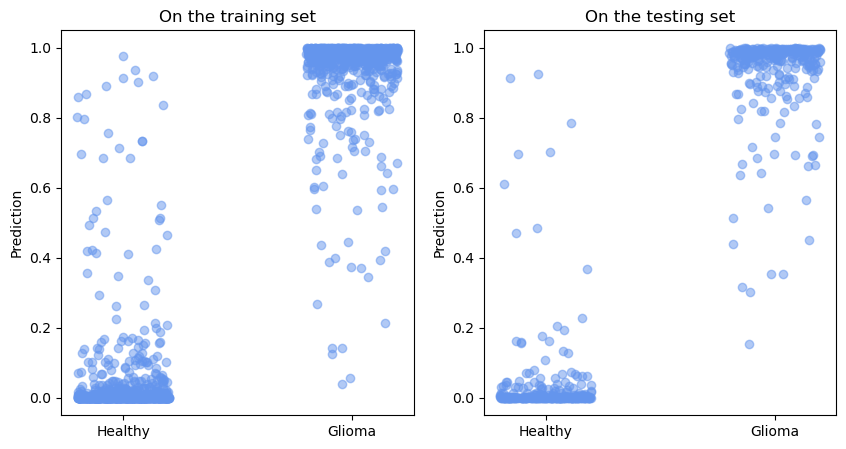

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(y_train.detach().numpy()[:, 0]+np.linspace(-0.2, 0.2, len(pred_on_train)), pred_on_train, alpha=0.5, c='cornflowerblue')
ax[0].set_ylabel('Prediction')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Healthy', 'Glioma'])
ax[0].set_title('On the training set')

ax[1].scatter(y_test.detach().numpy()[:, 0]+np.linspace(-0.2, 0.2, len(pred_on_test)), pred_on_test, alpha=0.5, c='cornflowerblue')
ax[1].set_ylabel('Prediction')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Healthy', 'Glioma'])
ax[1].set_title('On the testing set')

It's working: we hve few false positive.

We show here the disributions of the prediction for the healthy and tumour ground truth:

In [28]:
def compute_kde(pred, truth):
    healthy_ids = np.where(truth.detach().numpy()[:, 0] == 0)[0]
    glioma_ids = np.where(truth.detach().numpy()[:, 0] == 1)[0]

    kde_healthy = stats.gaussian_kde(pred[healthy_ids])
    kde_tumour = stats.gaussian_kde(pred[glioma_ids])
    return kde_healthy, kde_tumour


In [29]:
kde_healthy_pred_on_train, kde_tumour_pred_on_train = compute_kde(pred_on_train, y_train)
kde_healthy_pred_on_test, kde_tumour_pred_on_test = compute_kde(pred_on_test, y_test)

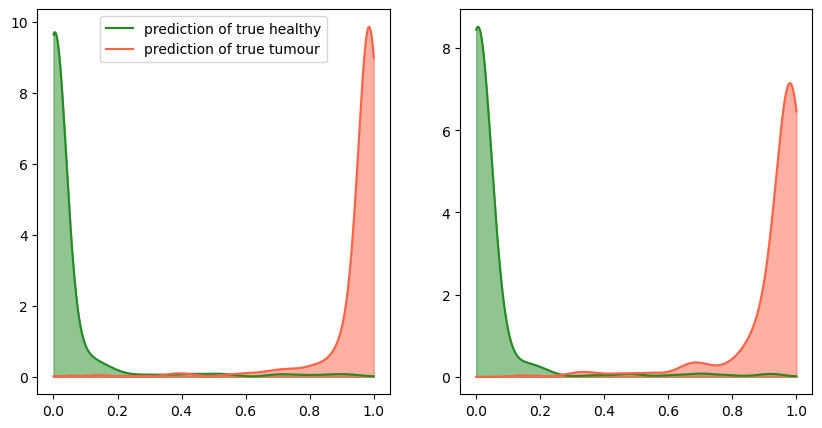

In [30]:
xx = np.linspace(0, 1, 1000)
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].plot(xx, kde_healthy_pred_on_train(xx), color='forestgreen', label='prediction of true healthy')
ax[0].fill_between(xx, kde_healthy_pred_on_train(xx), where=kde_healthy_pred_on_train(xx)>=np.zeros_like(xx), interpolate=True, color='forestgreen', alpha=0.5)

ax[0].plot(xx, kde_tumour_pred_on_train(xx), color='tomato', label='prediction of true tumour')
ax[0].fill_between(xx, kde_tumour_pred_on_train(xx), where=kde_tumour_pred_on_train(xx)>=np.zeros_like(xx), interpolate=True, color='tomato', alpha=0.5)


ax[1].plot(xx, kde_healthy_pred_on_test(xx), color='forestgreen',)
ax[1].fill_between(xx, kde_healthy_pred_on_test(xx), where=kde_healthy_pred_on_test(xx)>=np.zeros_like(xx), interpolate=True, color='forestgreen', alpha=0.5)

ax[1].plot(xx, kde_tumour_pred_on_test(xx), color='tomato',)
ax[1].fill_between(xx, kde_tumour_pred_on_test(xx), where=kde_tumour_pred_on_test(xx)>=np.zeros_like(xx), interpolate=True, color='tomato', alpha=0.5)

ax[0].legend()

Text(0.5, 0.98, 'Well classified healthy images                                                                          well classified tumour images')

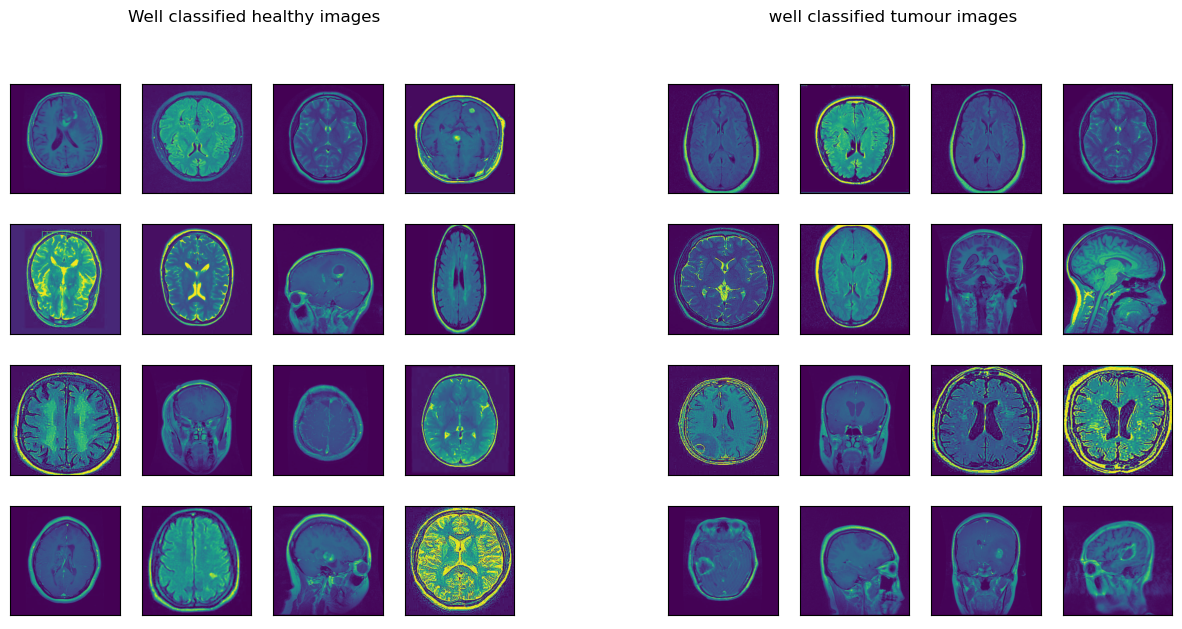

In [31]:
fig, ax = plt.subplots(4, 9, figsize=(15, 7))
good_healthy_ids = np.where((pred_on_test < 0.5 ) & (y_test.detach().numpy()[:, 0] == 0))[0]
k = 0
for i in range(4):
    for j in range(4):
        ax[i, j].imshow(x_train.detach().numpy()[good_healthy_ids[k], 0])
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        k += 1

good_tumour_ids = np.where((pred_on_test > 0.5 ) & (y_test.detach().numpy()[:, 0] == 1))[0]
k = 0
for i in range(4):
    for j in range(4):
        ax[i, j+5].imshow(x_train.detach().numpy()[good_tumour_ids[k], 0])
        ax[i, j+5].set_xticks([])
        ax[i, j+5].set_yticks([])
        k += 1

[axe.set_axis_off() for axe in ax[:, 4]]
plt.suptitle('Well classified healthy images                                                                          well classified tumour images') 

[ 24  78 123 128 260 328 489]


Text(0.5, 0.98, 'tumour classified as healthy                                                                                    healthy classifed as tumour')

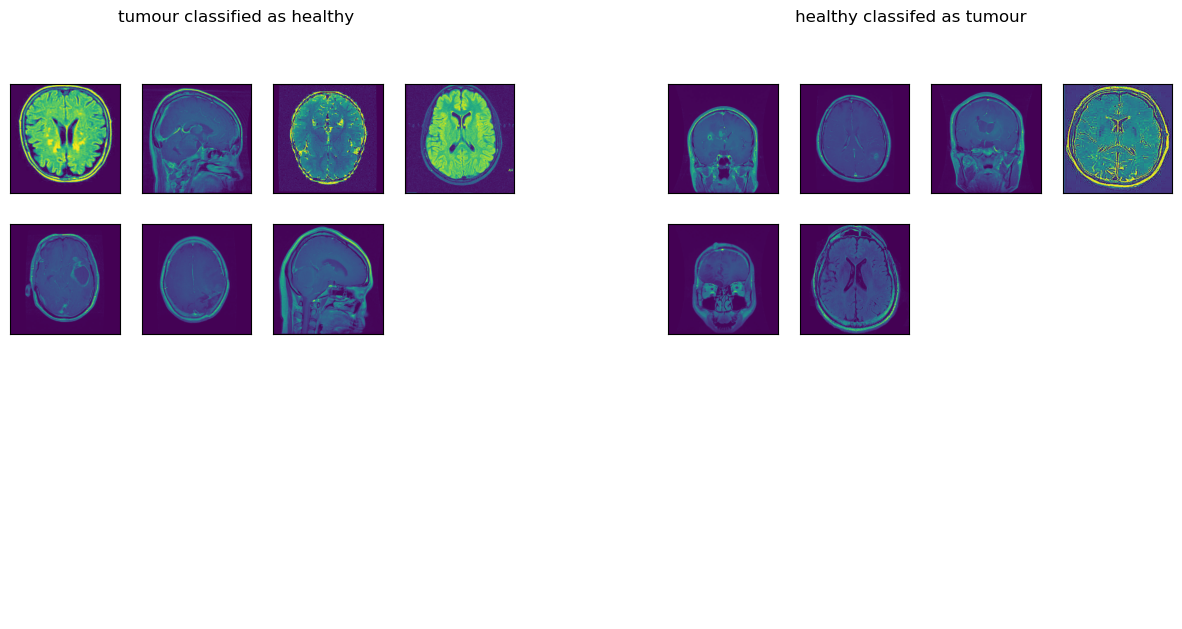

In [32]:
fig, ax = plt.subplots(4, 9, figsize=(15, 7))
wrong_healthy_ids = np.where((pred_on_test < 0.5 ) & (y_test.detach().numpy()[:, 0] == 1))[0]
print(wrong_healthy_ids)
k = 0
for i in range(4):
    for j in range(4):
        try:
            ax[i, j].imshow(x_train.detach().numpy()[wrong_healthy_ids[k], 0])
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            k += 1
        except IndexError:
            ax[i, j].set_axis_off()
            continue

wrong_tumour_ids = np.where((pred_on_test > 0.5 ) & (y_test.detach().numpy()[:, 0] == 0))[0]
k = 0
for i in range(4):
    for j in range(4):
        try:
            ax[i, j+5].imshow(x_train.detach().numpy()[wrong_tumour_ids[k], 0])
            ax[i, j+5].set_xticks([])
            ax[i, j+5].set_yticks([])
            k += 1
        except IndexError:
            ax[i, j+5].set_axis_off()
            continue

[axe.set_axis_off() for axe in ax[:, 4]]
plt.suptitle(f"tumour classified as healthy {' '*82} healthy classifed as tumour") 

In [33]:
def compute_confusion(pred, true):
    pred_int = np.rint(pred).astype(int)
    matrix = sklearn.metrics.confusion_matrix(true.detach().numpy().astype(int).flatten(), pred_int)
    return matrix

In [34]:
test_cf = compute_confusion(pred_on_test, y_test)

Text(0.5, 1.0, 'Confusion matrix on internal test')

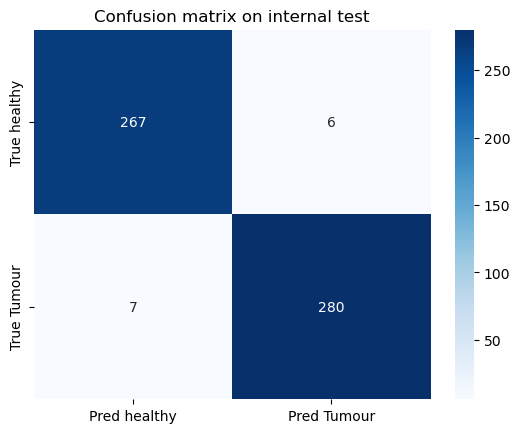

In [35]:
sns.heatmap(test_cf, annot=True, cmap='Blues', fmt='d')
plt.xticks([.5, 1.5], ['Pred healthy', 'Pred Tumour'])
plt.yticks([.5, 1.5], ['True healthy', 'True Tumour'])
plt.title('Confusion matrix on internal test')

# External Validation

In [36]:
ext_test_tumour, ext_test_healthy = load_tumour_healthy('Testing')

In [37]:
y = np.zeros(len(ext_test_tumour) + len(ext_test_healthy))
y[:len(ext_test_tumour)] = 1
x = np.concatenate((ext_test_tumour, ext_test_healthy))
shuffle = np.random.permutation(np.arange(0, len(x)))
x = x[shuffle]
y = y[shuffle]

x_norm = x - np.mean(x)
x_norm /= np.std(x_norm)

x_tensor = torch.from_numpy(np.expand_dims(x_norm, 0)).float()
y_tensor = torch.from_numpy(np.expand_dims(y, 1)).float()
x_test = x_tensor.transpose(0, 1) # transpose to have a shape (n_images, n_channels, height, width)


In [38]:
pred_on_ext_test = model_simple(x_test)
pred_on_ext_test = sigmoid(pred_on_ext_test.detach().numpy())[:, 0]

Text(0.5, 1.0, 'On the testing set')

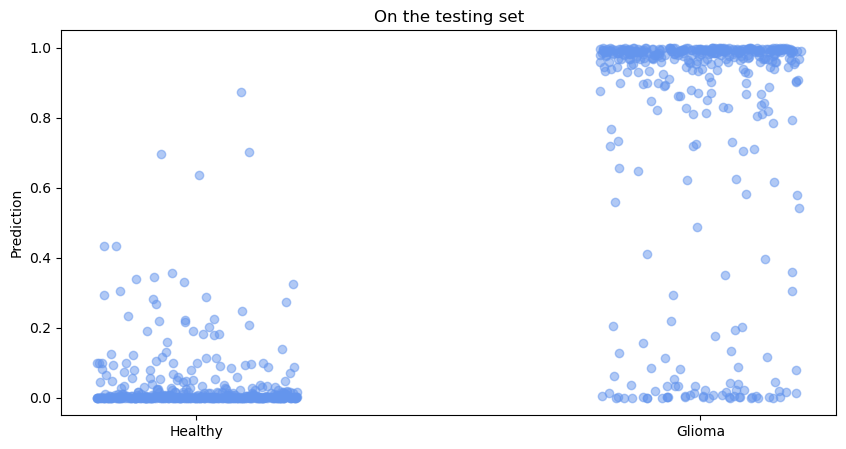

In [39]:
fig, ax = plt.subplots(1, figsize=(10, 5))
ax.scatter(y_tensor.detach().numpy()[:, 0]+np.linspace(-0.2, 0.2, len(pred_on_ext_test)), pred_on_ext_test, alpha=0.5, c='cornflowerblue')
ax.set_ylabel('Prediction')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Healthy', 'Glioma'])
ax.set_title('On the testing set')

Not as good in external validation!

In [40]:
kde_healthy_pred_on_test, kde_tumour_pred_on_test = compute_kde(pred_on_ext_test, y_tensor)

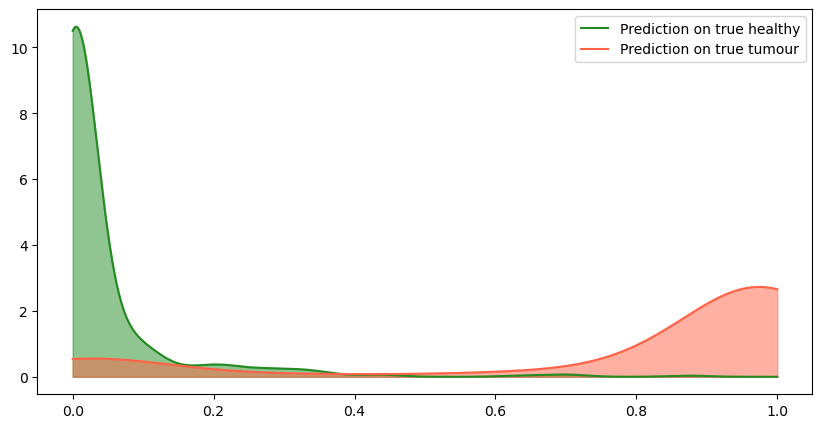

In [41]:
xx = np.linspace(0, 1, 1000)
fig, ax = plt.subplots(1,figsize=(10,5))


ax.plot(xx, kde_healthy_pred_on_test(xx), color='forestgreen', label='Prediction on true healthy')
ax.fill_between(xx, kde_healthy_pred_on_test(xx), where=kde_healthy_pred_on_test(xx)>=np.zeros_like(xx), interpolate=True, color='forestgreen', alpha=0.5)

ax.plot(xx, kde_tumour_pred_on_test(xx), color='tomato', label='Prediction on true tumour')
ax.fill_between(xx, kde_tumour_pred_on_test(xx), where=kde_tumour_pred_on_test(xx)>=np.zeros_like(xx), interpolate=True, color='tomato', alpha=0.5)
ax.legend()

In [42]:

external_validation_cf = compute_confusion(pred_on_ext_test, y_tensor)


Text(0.5, 1.0, 'Confusion matrix on external test')

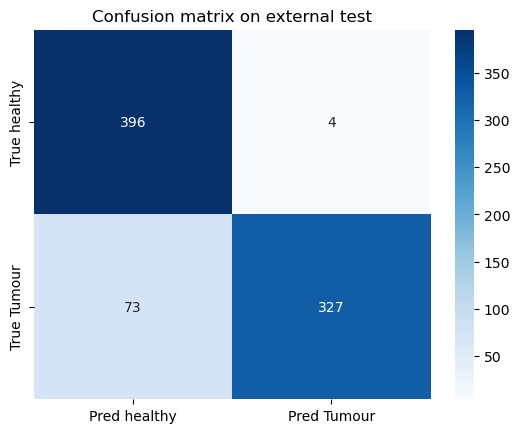

In [43]:
sns.heatmap(external_validation_cf, annot=True, cmap='Blues', fmt='d')
plt.xticks([.5, 1.5], ['Pred healthy', 'Pred Tumour'])
plt.yticks([.5, 1.5], ['True healthy', 'True Tumour'])
plt.title('Confusion matrix on external test')